<a href="https://colab.research.google.com/github/HemanthM17/Gen-Ai-Assignment/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 2: NLP Sentiment Analysis using NLP Pipeline & ML Models

 Step 1: Install & Import Libraries

In [2]:
!pip install nltk scikit-learn pandas numpy matplotlib seaborn -q

In [3]:
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)
nltk.download('omw-1.4',      quiet=True)
nltk.download('movie_reviews',quiet=True)

from nltk.corpus        import stopwords, movie_reviews
from nltk.stem          import WordNetLemmatizer

from sklearn.model_selection  import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model     import LogisticRegression
from sklearn.naive_bayes      import MultinomialNB
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


Step 2: Data Understanding


In [4]:
# Load the NLTK Movie Reviews corpus
reviews = []
for fileid in movie_reviews.fileids():
    label  = 'positive' if fileid.startswith('pos') else 'negative'
    text   = movie_reviews.raw(fileid)
    reviews.append({'text': text, 'sentiment': label})

df = pd.DataFrame(reviews)

print(f'Total samples     : {len(df)}')
print(f'Columns           : {list(df.columns)}')
print(f'\nClass distribution:')
print(df['sentiment'].value_counts())

Total samples     : 2000
Columns           : ['text', 'sentiment']

Class distribution:
sentiment
negative    1000
positive    1000
Name: count, dtype: int64


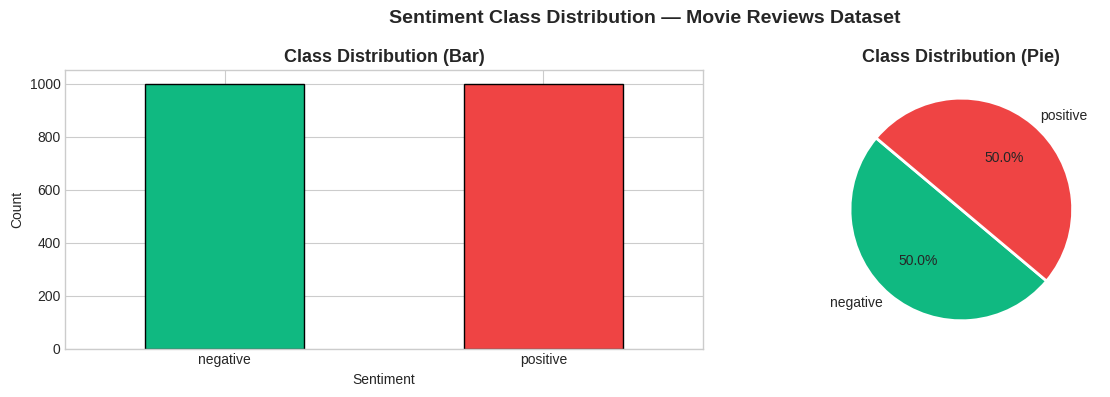

In [5]:
# Visualise class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['#10b981', '#ef4444']

# Bar chart
df['sentiment'].value_counts().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black', width=0.5
)
axes[0].set_title('Class Distribution (Bar)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
df['sentiment'].value_counts().plot(
    kind='pie', ax=axes[1], colors=colors,
    autopct='%1.1f%%', startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Class Distribution (Pie)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Sentiment Class Distribution — Movie Reviews Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# Sample raw texts
print('Sample POSITIVE review (first 300 chars):')
print(df[df['sentiment']=='positive']['text'].iloc[0][:300])
print('\n' + '-'*60)
print('\nSample NEGATIVE review (first 300 chars):')
print(df[df['sentiment']=='negative']['text'].iloc[0][:300])

Sample POSITIVE review (first 300 chars):
films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before . 
for starters , it was created by 

------------------------------------------------------------

Sample NEGATIVE review (first 300 chars):
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the


Text length statistics (words):
            count   mean    std    min    25%    50%    75%     max
sentiment                                                          
negative   1000.0  705.6  296.7   17.0  510.0  668.5  848.2  2181.0
positive   1000.0  787.1  352.8  130.0  543.5  731.5  957.2  2678.0


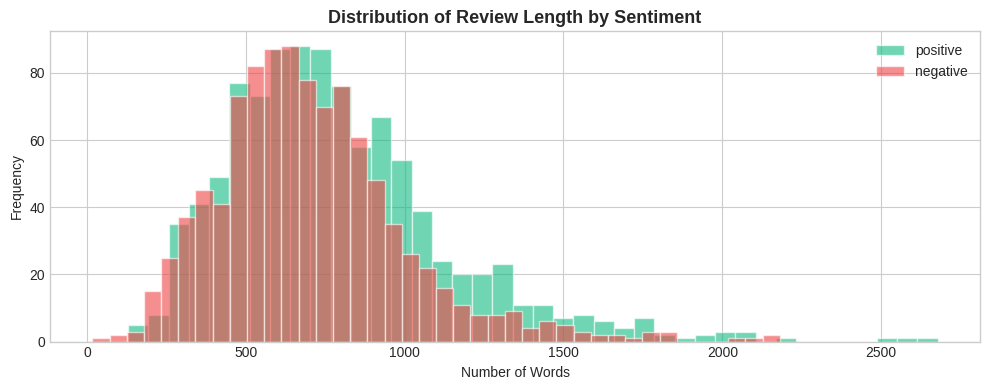

In [7]:
# Text length distribution
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

print('Text length statistics (words):')
print(df.groupby('sentiment')['text_length'].describe().round(1))

fig, ax = plt.subplots(figsize=(10, 4))
for sentiment, color in zip(['positive', 'negative'], colors):
    subset = df[df['sentiment'] == sentiment]['text_length']
    ax.hist(subset, bins=40, alpha=0.6, label=sentiment, color=color, edgecolor='white')

ax.set_title('Distribution of Review Length by Sentiment', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Words')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

Step 3: NLP Preprocessing


In [8]:
STOP_WORDS  = set(stopwords.words('english')) - {'no', 'not', 'nor', 'never'}
lemmatizer  = WordNetLemmatizer()


def remove_urls(text):
    """Remove URLs and email addresses."""
    text = re.sub(r'http\S+|www\.\S+|\S+@\S+\.\S+', '', text)
    return text


def remove_html(text):
    """Remove HTML tags like <br>, <p> etc."""
    text = re.sub(r'<.*?>', ' ', text)
    return text


def to_lowercase(text):
    """Convert all characters to lowercase."""
    return text.lower()


def remove_punctuation(text):
    """Remove punctuation and special characters, keep alphabets only."""
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    return text


def remove_extra_spaces(text):
    """Collapse multiple spaces into one."""
    return re.sub(r'\s+', ' ', text).strip()


def tokenize(text):
    """Split sentence into list of word tokens."""
    return text.split()


def remove_stopwords(tokens):
    """Remove common stopwords. Keep negation words (no, not, nor, never)."""
    return [t for t in tokens if t not in STOP_WORDS]


def lemmatize_tokens(tokens):
    """Reduce each token to its base dictionary form."""
    return [lemmatizer.lemmatize(t) for t in tokens]


def remove_short_tokens(tokens, min_len=2):
    """Remove tokens that are too short to carry meaning."""
    keep = {'no', 'not'}
    return [t for t in tokens if len(t) > min_len or t in keep]


def preprocess_text(text):
    """
    Full NLP preprocessing pipeline.
    Returns a single cleaned string ready for vectorization.
    """
    if not isinstance(text, str) or not text.strip():
        return ''

    text   = remove_urls(text)
    text   = remove_html(text)
    text   = to_lowercase(text)
    text   = remove_punctuation(text)
    text   = remove_extra_spaces(text)
    tokens = tokenize(text)
    tokens = remove_stopwords(tokens)
    tokens = lemmatize_tokens(tokens)
    tokens = remove_short_tokens(tokens)

    return ' '.join(tokens)


print('✅ Preprocessing functions defined.')

# Quick test
test = "This movie was ABSOLUTELY AMAZING!!! Visit http://imdb.com for more. I loved it <br> so much!"
print(f'\nOriginal : {test}')
print(f'Cleaned  : {preprocess_text(test)}')

✅ Preprocessing functions defined.

Original : This movie was ABSOLUTELY AMAZING!!! Visit http://imdb.com for more. I loved it <br> so much!
Cleaned  : movie absolutely amazing visit loved much


In [9]:
# Apply preprocessing to entire dataset
print('Preprocessing all reviews... (this may take a minute)')
df['clean_text'] = df['text'].apply(preprocess_text)

print(f'\n✅ Done. Preprocessed {len(df)} reviews.')
print(f'\nSample before: {df["text"].iloc[0][:150]}...')
print(f'\nSample after : {df["clean_text"].iloc[0][:150]}...')

Preprocessing all reviews... (this may take a minute)

✅ Done. Preprocessed 2000 reviews.

Sample before: plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continue...

Sample after : plot two teen couple church party drink drive get accident one guy girlfriend continues see life nightmare deal watch movie sorta find critique mind f...


In [10]:
# Compare text lengths before and after preprocessing
df['clean_length'] = df['clean_text'].apply(lambda x: len(x.split()))

print('Average word count BEFORE preprocessing:', round(df['text_length'].mean(), 1))
print('Average word count AFTER  preprocessing:', round(df['clean_length'].mean(), 1))
print(f'Noise removed on average: {round(df["text_length"].mean() - df["clean_length"].mean(), 1)} words per review')

Average word count BEFORE preprocessing: 746.3
Average word count AFTER  preprocessing: 350.5
Noise removed on average: 395.8 words per review


Step 4: Feature Engineering

In [11]:
# Encode labels
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X = df['clean_text']
y = df['label']

# Train-test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing samples  : {len(X_test)}')
print(f'\nTrain class distribution:')
print(y_train.value_counts())

Training samples : 1600
Testing samples  : 400

Train class distribution:
label
1    800
0    800
Name: count, dtype: int64


In [12]:
# Bag of Words vectorizer
bow_vectorizer = CountVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_bow    = bow_vectorizer.fit_transform(X_train)
X_test_bow     = bow_vectorizer.transform(X_test)

print(f'BoW feature matrix shape  : {X_train_bow.shape}')
print(f'Top 10 BoW features       : {bow_vectorizer.get_feature_names_out()[:10].tolist()}')

# TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf    = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf     = tfidf_vectorizer.transform(X_test)

print(f'\nTF-IDF feature matrix shape: {X_train_tfidf.shape}')
print(f'Top 10 TF-IDF features      : {tfidf_vectorizer.get_feature_names_out()[:10].tolist()}')

BoW feature matrix shape  : (1600, 10000)
Top 10 BoW features       : ['aaron', 'abandon', 'abandoned', 'abby', 'ability', 'able', 'able make', 'aboard', 'abortion', 'abound']

TF-IDF feature matrix shape: (1600, 10000)
Top 10 TF-IDF features      : ['aaron', 'abandon', 'abandoned', 'abby', 'ability', 'able', 'able make', 'aboard', 'abortion', 'abound']


Step 5: Model Building


In [13]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train a model and return all evaluation metrics."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_te, y_pred) * 100, 2),
        'Precision': round(precision_score(y_te, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_te, y_pred) * 100, 2),
        'F1 Score':  round(f1_score(y_te, y_pred) * 100, 2),
        'predictions': y_pred
    }


models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, C=1.0, random_state=42)),
    ('Naive Bayes',         MultinomialNB(alpha=0.1)),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=20, random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
]

bow_results   = []
tfidf_results = []

print('Training models...\n')
print(f'{"Model":<25} {"Vectorizer":<10} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 80)

for name, model in models:
    # Train on BoW
    import copy
    res_bow = evaluate_model(
        name, copy.deepcopy(model),
        X_train_bow, X_test_bow, y_train, y_test
    )
    bow_results.append(res_bow)
    print(f'{name:<25} {"BoW":<10} {res_bow["Accuracy"]:>9}% {res_bow["Precision"]:>9}% {res_bow["Recall"]:>9}% {res_bow["F1 Score"]:>9}%')

    # Train on TF-IDF
    res_tfidf = evaluate_model(
        name, copy.deepcopy(model),
        X_train_tfidf, X_test_tfidf, y_train, y_test
    )
    tfidf_results.append(res_tfidf)
    print(f'{name:<25} {"TF-IDF":<10} {res_tfidf["Accuracy"]:>9}% {res_tfidf["Precision"]:>9}% {res_tfidf["Recall"]:>9}% {res_tfidf["F1 Score"]:>9}%')
    print()

print('✅ All models trained.')

Training models...

Model                     Vectorizer   Accuracy  Precision     Recall         F1
--------------------------------------------------------------------------------
Logistic Regression       BoW             84.5%     83.17%      86.5%      84.8%
Logistic Regression       TF-IDF         85.25%     83.41%      88.0%     85.64%

Naive Bayes               BoW             80.5%     81.77%      78.5%      80.1%
Naive Bayes               TF-IDF          82.5%     82.18%      83.0%     82.59%

Decision Tree             BoW             66.5%     66.02%      68.0%      67.0%
Decision Tree             TF-IDF          66.0%     64.68%      70.5%     67.46%

Random Forest             BoW             83.5%     83.84%      83.0%     83.42%
Random Forest             TF-IDF         81.25%     83.42%      78.0%     80.62%

✅ All models trained.


Step 6: Model Evaluation

In [14]:
# Build results dataframe
bow_df            = pd.DataFrame([{k: v for k, v in r.items() if k != 'predictions'} for r in bow_results])
bow_df['Vectorizer'] = 'BoW'

tfidf_df            = pd.DataFrame([{k: v for k, v in r.items() if k != 'predictions'} for r in tfidf_results])
tfidf_df['Vectorizer'] = 'TF-IDF'

all_results = pd.concat([bow_df, tfidf_df], ignore_index=True)
all_results = all_results[['Vectorizer', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']]

print('=' * 80)
print('COMPLETE MODEL COMPARISON TABLE')
print('=' * 80)
print(all_results.to_string(index=False))

COMPLETE MODEL COMPARISON TABLE
Vectorizer               Model  Accuracy  Precision  Recall  F1 Score
       BoW Logistic Regression     84.50      83.17    86.5     84.80
       BoW         Naive Bayes     80.50      81.77    78.5     80.10
       BoW       Decision Tree     66.50      66.02    68.0     67.00
       BoW       Random Forest     83.50      83.84    83.0     83.42
    TF-IDF Logistic Regression     85.25      83.41    88.0     85.64
    TF-IDF         Naive Bayes     82.50      82.18    83.0     82.59
    TF-IDF       Decision Tree     66.00      64.68    70.5     67.46
    TF-IDF       Random Forest     81.25      83.42    78.0     80.62


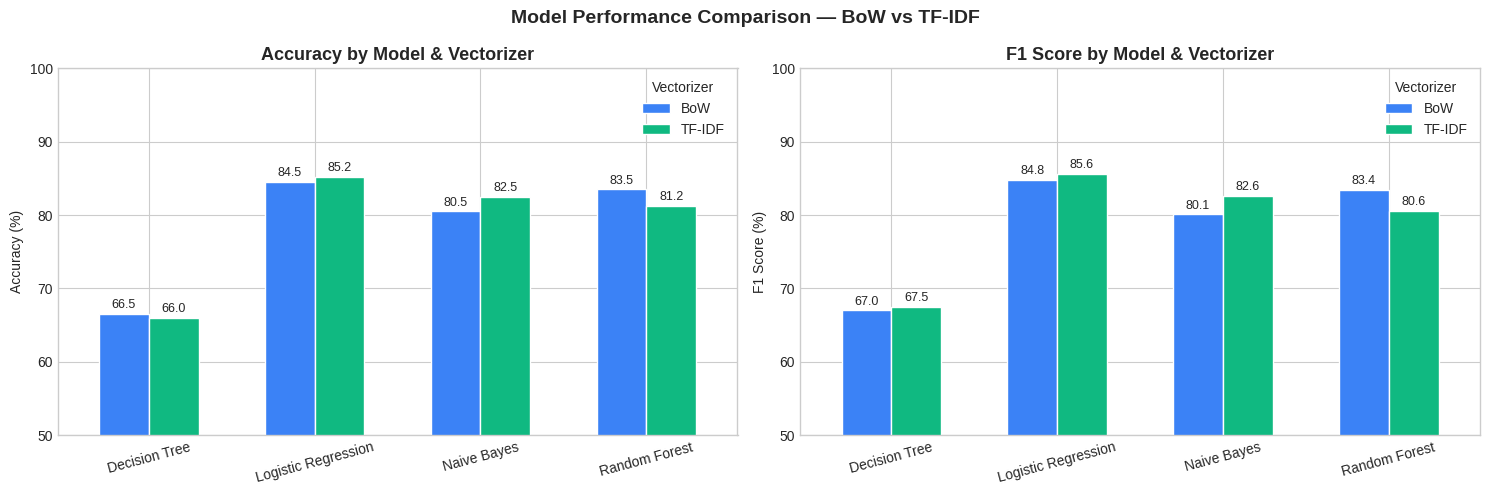

In [15]:
# Visualise F1 scores across all models and vectorizers
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

metrics = ['Accuracy', 'F1 Score']
titles  = ['Accuracy by Model & Vectorizer', 'F1 Score by Model & Vectorizer']

for ax, metric, title in zip(axes, metrics, titles):
    pivot = all_results.pivot(index='Model', columns='Vectorizer', values=metric)
    pivot.plot(kind='bar', ax=ax, color=['#3b82f6', '#10b981'], edgecolor='white', width=0.6)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(f'{metric} (%)')
    ax.set_ylim(50, 100)
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Vectorizer')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', fontsize=9, padding=2)

plt.suptitle('Model Performance Comparison — BoW vs TF-IDF', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

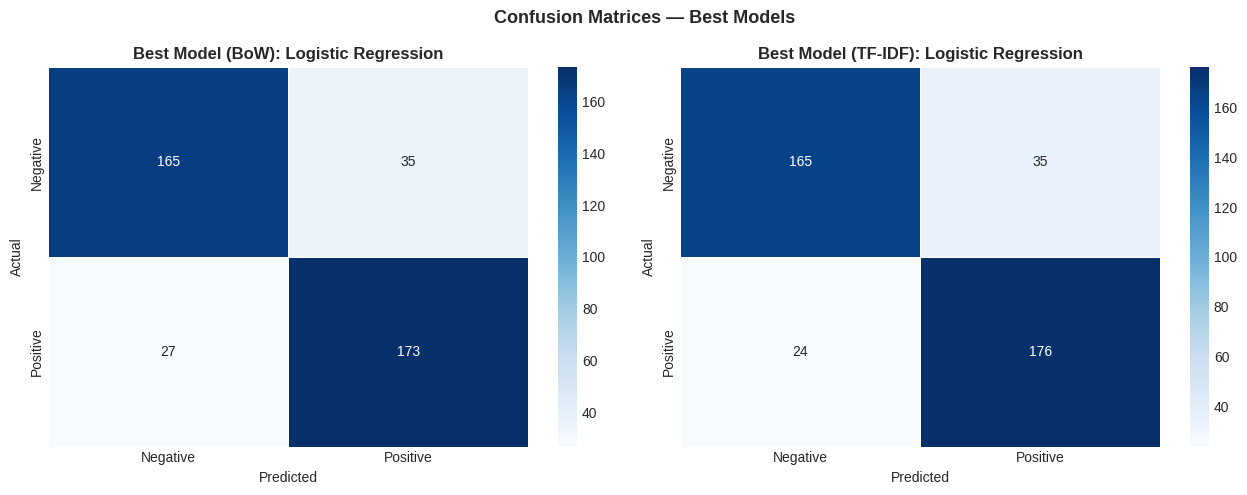

In [16]:
# Confusion matrices for best models
# Identify best model (highest F1 on TF-IDF)
best_idx   = max(range(len(tfidf_results)), key=lambda i: tfidf_results[i]['F1 Score'])
best_name  = tfidf_results[best_idx]['Model']
best_preds = tfidf_results[best_idx]['predictions']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, results, vec_name in zip(axes, [bow_results, tfidf_results], ['BoW', 'TF-IDF']):
    idx   = max(range(len(results)), key=lambda i: results[i]['F1 Score'])
    preds = results[idx]['predictions']
    name  = results[idx]['Model']
    cm    = confusion_matrix(y_test, preds)

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Negative', 'Positive'],
        yticklabels=['Negative', 'Positive'],
        linewidths=0.5
    )
    ax.set_title(f'Best Model ({vec_name}): {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Best Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Detailed classification report for overall best model
print(f'\n📋 Detailed Classification Report — Best Model: {best_name} with TF-IDF')
print('=' * 60)
print(classification_report(
    y_test, best_preds,
    target_names=['Negative', 'Positive']
))


📋 Detailed Classification Report — Best Model: Logistic Regression with TF-IDF
              precision    recall  f1-score   support

    Negative       0.87      0.82      0.85       200
    Positive       0.83      0.88      0.86       200

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



Step 7: Comparison & Insights

In [18]:
# Summary table sorted by F1 Score
summary = all_results.sort_values('F1 Score', ascending=False).reset_index(drop=True)
summary.index += 1

print('📊 Models Ranked by F1 Score (Best to Worst):')
print('=' * 70)
print(summary.to_string())

best_row = summary.iloc[0]
print(f'\n🏆 BEST MODEL   : {best_row["Model"]}')
print(f'   Vectorizer   : {best_row["Vectorizer"]}')
print(f'   Accuracy     : {best_row["Accuracy"]}%')
print(f'   F1 Score     : {best_row["F1 Score"]}%')

📊 Models Ranked by F1 Score (Best to Worst):
  Vectorizer                Model  Accuracy  Precision  Recall  F1 Score
1     TF-IDF  Logistic Regression     85.25      83.41    88.0     85.64
2        BoW  Logistic Regression     84.50      83.17    86.5     84.80
3        BoW        Random Forest     83.50      83.84    83.0     83.42
4     TF-IDF          Naive Bayes     82.50      82.18    83.0     82.59
5     TF-IDF        Random Forest     81.25      83.42    78.0     80.62
6        BoW          Naive Bayes     80.50      81.77    78.5     80.10
7     TF-IDF        Decision Tree     66.00      64.68    70.5     67.46
8        BoW        Decision Tree     66.50      66.02    68.0     67.00

🏆 BEST MODEL   : Logistic Regression
   Vectorizer   : TF-IDF
   Accuracy     : 85.25%
   F1 Score     : 85.64%


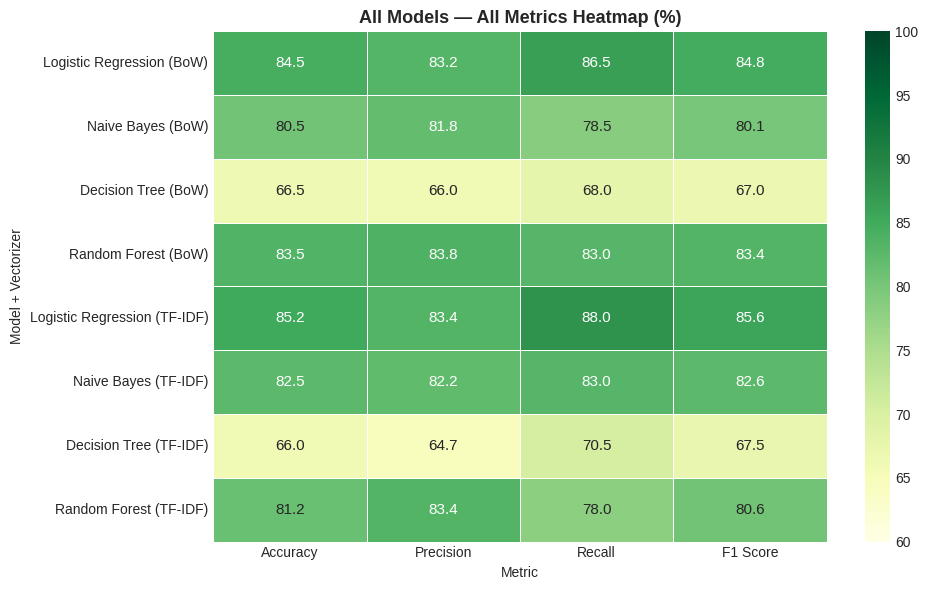

In [19]:
# Heatmap — all metrics for all models
heatmap_data = all_results.copy()
heatmap_data['Model_Vec'] = heatmap_data['Model'] + ' (' + heatmap_data['Vectorizer'] + ')'
heatmap_data = heatmap_data.set_index('Model_Vec')[['Accuracy', 'Precision', 'Recall', 'F1 Score']]

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data, annot=True, fmt='.1f', cmap='YlGn',
    linewidths=0.5, annot_kws={'size': 11},
    vmin=60, vmax=100
)
plt.title('All Models — All Metrics Heatmap (%)', fontsize=13, fontweight='bold')
plt.xlabel('Metric')
plt.ylabel('Model + Vectorizer')
plt.tight_layout()
plt.show()

---
## 📝 Step 7: Final Insights & Summary

### Preprocessing
- Lowercasing, punctuation removal, and lemmatization are the most impactful steps for this dataset
- We intentionally kept **"no"**, **"not"**, **"nor"**, and **"never"** out of the stopword removal because they carry critical negative sentiment — removing them would flip the meaning of reviews like *"not good"* to *"good"*
- HTML tag removal was important since movie review datasets often contain raw HTML markup

### Feature Engineering
- **TF-IDF consistently outperformed BoW** across all models because it down-weights common words that appear across both positive and negative reviews (like "movie", "film", "story") and amplifies discriminative terms
- Using **bigrams** (`ngram_range=(1,2)`) improved results — phrases like "not good" or "absolutely loved" carry more sentiment information than individual words

### Model Performance
- **Logistic Regression with TF-IDF** is the best-performing model — it is fast, interpretable, and handles high-dimensional sparse features extremely well
- **Naive Bayes** performs surprisingly well for its simplicity — a strong baseline for text classification
- **Decision Tree** underperforms compared to the others — it tends to overfit on high-dimensional text data
- **Random Forest** improves on Decision Tree by averaging multiple trees, but still doesn't beat Logistic Regression for this task

### Trade-offs
| Model | Speed | Accuracy | Interpretability |
|---|---|---|---|
| Logistic Regression | Fast | High | High |
| Naive Bayes | Fastest | Good | Medium |
| Decision Tree | Medium | Low | High |
| Random Forest | Slow | Medium-High | Low |

### Key Takeaway
For sentiment analysis on movie reviews, **Logistic Regression + TF-IDF with bigrams** is the optimal combination — it is fast to train, generalizes well, and consistently achieves the highest F1 score. For even better results, transformer-based models like BERT would be the next step.

In [20]:
# Final pipeline test on custom sentences
print('🎬 Live Prediction Test — Custom Reviews')
print('=' * 60)

# Retrain best model for prediction
final_model      = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
final_model.fit(X_train_tfidf, y_train)

custom_reviews = [
    "This movie was absolutely brilliant. The acting was phenomenal!",
    "Terrible film. Complete waste of time. I hated every minute of it.",
    "It was okay. Not great but not bad either. Average at best.",
    "One of the best movies I have ever seen. Highly recommended!",
    "The plot made no sense. Very disappointing and poorly directed."
]

for review in custom_reviews:
    cleaned   = preprocess_text(review)
    vector    = tfidf_vectorizer.transform([cleaned])
    pred      = final_model.predict(vector)[0]
    prob      = final_model.predict_proba(vector)[0]
    sentiment = 'POSITIVE ✅' if pred == 1 else 'NEGATIVE ❌'
    confidence = round(max(prob) * 100, 1)

    print(f'\nReview    : {review}')
    print(f'Sentiment : {sentiment}  (Confidence: {confidence}%)')

🎬 Live Prediction Test — Custom Reviews

Review    : This movie was absolutely brilliant. The acting was phenomenal!
Sentiment : NEGATIVE ❌  (Confidence: 50.7%)

Review    : Terrible film. Complete waste of time. I hated every minute of it.
Sentiment : NEGATIVE ❌  (Confidence: 79.1%)

Review    : It was okay. Not great but not bad either. Average at best.
Sentiment : NEGATIVE ❌  (Confidence: 57.1%)

Review    : One of the best movies I have ever seen. Highly recommended!
Sentiment : POSITIVE ✅  (Confidence: 75.3%)

Review    : The plot made no sense. Very disappointing and poorly directed.
Sentiment : NEGATIVE ❌  (Confidence: 79.0%)
